# ✈️ DelayPredict — 03b XGBoost

**Goal:** Train an XGBoost classifier and compare it against the baseline (Logistic Regression) and Random Forest.

This notebook is **self-contained** — it loads raw data and performs all feature engineering internally.  
No dependency on previous notebooks at runtime, except `baseline_metrics.csv` and `rf_metrics.csv` for the comparison table.

---
**Input:** `data/raw/airlines_delay.csv`  
**Input (optional):** `data/processed/baseline_metrics.csv`, `data/processed/rf_metrics.csv`  
**Output:** `models/xgb_model.pkl`, `data/processed/xgb_metrics.csv`  
**MLflow:** Run is logged automatically at the end of this notebook  

---
**Why XGBoost?**  
XGBoost (Extreme Gradient Boosting) builds trees **sequentially** — each tree corrects the errors of the previous one.  
This often outperforms Random Forest, especially on tabular data, at the cost of slightly more complexity.

## 1. Setup and Imports

In [19]:
# Install dependencies if not already present
import subprocess
subprocess.run(["pip", "install", "mlflow", "xgboost"], check=True)


CompletedProcess(args=['pip', 'install', 'mlflow', 'xgboost'], returncode=0)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

import joblib
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42  # fixed seed for reproducibility


## 2. Load Raw Data

Always loads from the **raw dataset** and performs feature engineering itself.  
This keeps the notebook fully self-contained and independent of `01_eda.ipynb`.

In [21]:
RAW_PATH = Path("../data/raw/airlines_delay.csv")

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {RAW_PATH}.\n"
        "Please place airlines_delay.csv in data/raw/"
    )

df = pd.read_csv(RAW_PATH)

print("Source :", RAW_PATH)
print("Shape  :", df.shape)
display(df.head())


Source : ..\data\raw\airlines_delay.csv
Shape  : (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 3. Feature Engineering

All transformations applied from scratch — identical logic to `03a_random_forest.ipynb`.

| Raw Column | Action | Reason |
|---|---|---|
| `Time` | `// 60` → `DepartureHour` | Time is minutes since midnight (0–1439) |
| `id` | Drop | Row identifier, no signal |
| `Flight` | Drop | High cardinality, weak generalization |
| `Time` | Drop | Replaced by `DepartureHour` |

In [22]:
# ── Derive DepartureHour from Time ──────────────────────────────────────────
# Time is stored as minutes since midnight (0 = 00:00, 1439 = 23:59)
df["DepartureHour"] = df["Time"] // 60

# ── Drop columns not used for modeling ──────────────────────────────────────
# id     : row identifier only
# Flight : 6,585 unique values — too high cardinality, poor generalization
# Time   : replaced by DepartureHour
DROP_COLS = ["id", "Flight", "Time"]
df = df.drop(columns=DROP_COLS)

print("Columns after feature engineering:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())


Columns after feature engineering: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'Delay', 'DepartureHour']
Shape: (539383, 7)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,Delay,DepartureHour
0,CO,SFO,IAH,3,205,1,0
1,US,PHX,CLT,3,222,1,0
2,AA,LAX,DFW,3,165,1,0
3,AA,SFO,DFW,3,195,1,0
4,AS,ANC,SEA,3,202,0,0


## 4. Features and Target

**Target:** `Delay` — 1 if the flight arrived more than 15 minutes late, 0 otherwise.

In [23]:
TARGET = "Delay"

X = df.drop(columns=[TARGET])  # feature matrix
y = df[TARGET]                  # target vector (0 = no delay, 1 = delay)

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()

# Class distribution
dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']
X shape : (539383, 6)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64

## 5. Feature Types

| Feature | Type | Preprocessing | Reason |
|---|---|---|---|
| Airline | Categorical | OneHotEncoder | 18 carriers |
| AirportFrom | Categorical | OneHotEncoder | 293 airports |
| AirportTo | Categorical | OneHotEncoder | 293 airports |
| DayOfWeek | Categorical | OneHotEncoder | No linear order for delay risk |
| Length | Numeric | None | Tree-based — no scaling needed |
| DepartureHour | Numeric | None | Tree-based — no scaling needed |

> Like Random Forest, XGBoost is **scale-invariant** — no StandardScaler needed.

In [24]:
# Categorical features → OneHotEncoding
CATEGORICAL = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek"]

# Numeric features → passed through as-is (no scaling needed for tree models)
NUMERIC = ["Length", "DepartureHour"]

# Verify all expected features are present
assert all(f in X.columns for f in CATEGORICAL + NUMERIC), \
    "Feature mismatch — check dataset columns."

print("Categorical:", CATEGORICAL)
print("Numeric    :", NUMERIC)


Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']
Numeric    : ['Length', 'DepartureHour']


## 6. Train / Test Split

- **80 / 20** split — same ratio as baseline and Random Forest for a fair comparison
- `stratify=y` — preserves class ratio in both splits
- `random_state=42` — same seed across all notebooks for identical splits

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # ensures same class ratio in train and test
)

# Confirm delay rate is consistent across splits
print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 6)  |  delay rate: 0.445
Test : (107877, 6)   |  delay rate: 0.445


## 7. Preprocessing Pipeline

Same structure as `03a_random_forest.ipynb` — OHE for categoricals, passthrough for numerics.

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: passthrough — XGBoost is invariant to feature scale
        ("num", "passthrough", NUMERIC),

        # Categorical: one-hot encode
        # handle_unknown='ignore' → unseen categories at inference produce all-zero row
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ],
    remainder="drop",  # drop any unlisted columns
)


## 8. XGBoost Model

**How XGBoost differs from Random Forest:**

| | Random Forest | XGBoost |
|---|---|---|
| Tree building | Parallel (independent trees) | Sequential (each tree fixes previous errors) |
| Bias/Variance | Lower bias, higher variance | Lower variance, slightly higher bias |
| Speed | Fast | Fast (optimized C++ backend) |
| Tuning | Fewer parameters | More parameters, more sensitive |

**Hyperparameters (defaults — tuning in a later step if needed):**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | Number of boosting rounds |
| `max_depth` | 6 | XGBoost default — shallower than RF by design |
| `learning_rate` | 0.3 | XGBoost default — controls step size per round |
| `eval_metric` | logloss | Standard metric for binary classification |
| `use_label_encoder` | False | Avoids deprecation warning |

In [27]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,      # number of boosting rounds
        max_depth=6,           # maximum tree depth — XGBoost default
        learning_rate=0.3,     # step size per boosting round — XGBoost default
        eval_metric="logloss", # evaluation metric for binary classification
        n_jobs=-1,             # parallelise across all CPU cores
        random_state=RANDOM_STATE,
    )),
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost trained successfully.")


XGBoost trained successfully.


## 9. Evaluate

Evaluate XGBoost on the held-out test set.

In [28]:
y_pred_xgb  = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]  # probability of delay

xgb_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_xgb, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_xgb),
}

print("XGBoost metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print()
print(classification_report(
    y_test, y_pred_xgb,
    target_names=["No Delay", "Delay"],
    zero_division=0
))


XGBoost metrics:
  Accuracy  : 0.6647
  Precision : 0.6739
  Recall    : 0.4790
  F1        : 0.5600
  ROC-AUC   : 0.7150

              precision    recall  f1-score   support

    No Delay       0.66      0.81      0.73     59824
       Delay       0.67      0.48      0.56     48053

    accuracy                           0.66    107877
   macro avg       0.67      0.65      0.64    107877
weighted avg       0.67      0.66      0.65    107877



## 10. Comparison Against All Models

Load previously saved metrics from `02_baseline.ipynb` and `03a_random_forest.ipynb`  
and add XGBoost results for a full side-by-side comparison.

In [29]:
BASELINE_METRICS_PATH = Path("../data/processed/baseline_metrics.csv")
RF_METRICS_PATH       = Path("../data/processed/rf_metrics.csv")

xgb_row = {"model": "XGBoost", **xgb_metrics}

# Collect all available prior results
prior_frames = []
if BASELINE_METRICS_PATH.exists():
    prior_frames.append(pd.read_csv(BASELINE_METRICS_PATH))
else:
    print("baseline_metrics.csv not found — run 02_baseline.ipynb for full comparison.")

if RF_METRICS_PATH.exists():
    prior_frames.append(pd.read_csv(RF_METRICS_PATH))
else:
    print("rf_metrics.csv not found — run 03a_random_forest.ipynb for full comparison.")

# Build comparison table
comparison_df = pd.concat(
    prior_frames + [pd.DataFrame([xgb_row])],
    ignore_index=True
)

display(comparison_df.round(4))


,model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DummyClassifier,0.5546,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.6464,0.6345,0.4862,0.5506,0.6921
2,RandomForest,0.6538,0.6699,0.4391,0.5305,0.7019
3,XGBoost,0.6647,0.6739,0.4790,0.5600,0.7150


## 11. Confusion Matrix

- **True Negatives (top-left):** correctly predicted No Delay
- **False Positives (top-right):** predicted Delay, actually No Delay
- **False Negatives (bottom-left):** predicted No Delay, actually Delay ← the costly error
- **True Positives (bottom-right):** correctly predicted Delay

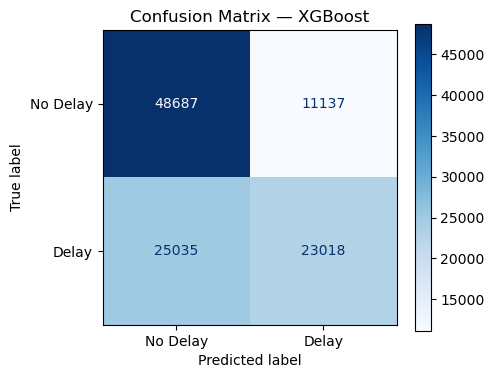

In [30]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()


## 12. ROC Curve and Precision-Recall Curve

**ROC Curve** — AUC = 0.5 is random guessing. Higher is better.  
**Precision-Recall Curve** — the dashed line is the no-skill baseline (= delay rate in test set).

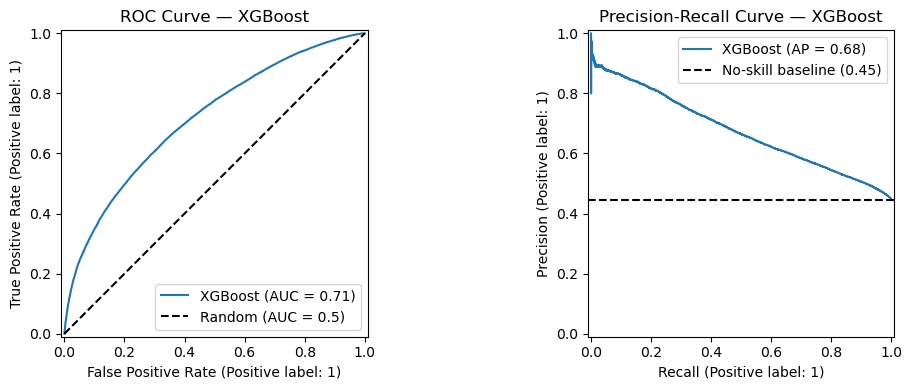

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=ax1, name="XGBoost")
ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax1.set_title("ROC Curve — XGBoost")
ax1.legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, ax=ax2, name="XGBoost")
ax2.axhline(y_test.mean(), color="k", linestyle="--",
            label=f"No-skill baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve — XGBoost")
ax2.legend()

plt.tight_layout()
plt.show()


## 13. Feature Importance

XGBoost provides feature importance based on how often each feature is used to split  
across all trees (`weight`). Compare this to the Random Forest importances from `03a`.

Top 20 most important features:


,Feature,Importance
0,Airline_WN,0.211575
1,Airline_CO,0.026904
2,Airline_YV,0.017455
3,Airline_OO,0.014048
4,AirportFrom_ORD,0.013794
5,AirportTo_SFO,0.011591
6,AirportFrom_TPA,0.010760
7,AirportFrom_DTW,0.009984
8,AirportFrom_RSW,0.009906
9,AirportFrom_SFO,0.009278


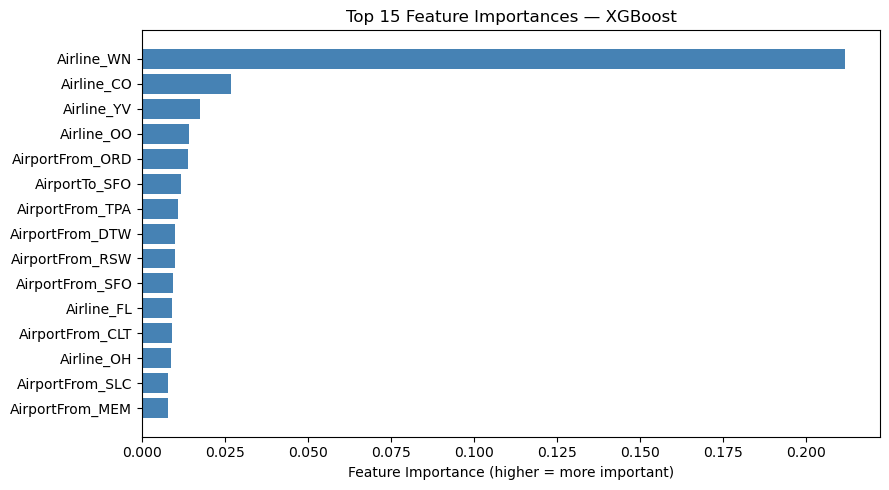

In [32]:
# Extract feature names after OHE transformation
ohe_names = (
    xgb_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
# Full feature name list: numeric first (passthrough order), then OHE
feature_names = NUMERIC + ohe_names
importances   = xgb_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most important features:")
display(importance_df.head(20))

# ── Bar chart: top 15 features ───────────────────────────────────────────────
top15 = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(top15["Feature"], top15["Importance"], color="steelblue")
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Feature Importance (higher = more important)")
plt.tight_layout()
plt.show()


## 14. Predicted Probability Distribution

A well-calibrated model pushes probabilities toward 0 and 1.  
Compare this to the distributions from `02_baseline.ipynb` and `03a_random_forest.ipynb`.

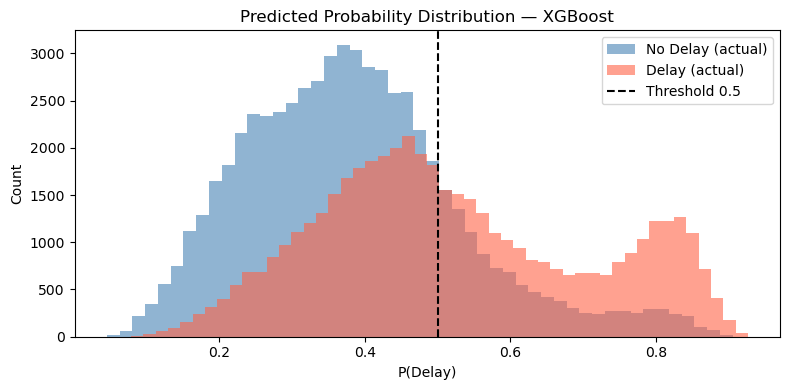

In [33]:
plt.figure(figsize=(8, 4))

# Distribution for flights that were NOT delayed
plt.hist(y_proba_xgb[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")

# Distribution for flights that WERE delayed
plt.hist(y_proba_xgb[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)", color="tomato")

# Default decision threshold
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")

plt.title("Predicted Probability Distribution — XGBoost")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Save Model and Metrics

- **Model** saved as `.pkl` for use in the FastAPI inference endpoint
- **Metrics CSV** saved for reference

In [34]:
# ── Save trained model ───────────────────────────────────────────────────────
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "xgb_model.pkl"
joblib.dump(xgb_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# ── Save XGBoost metrics CSV ─────────────────────────────────────────────────
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

xgb_metrics_df = pd.DataFrame([{"model": "XGBoost", **xgb_metrics}])
XGB_METRICS_PATH = OUTPUT_DIR / "xgb_metrics.csv"
xgb_metrics_df.to_csv(XGB_METRICS_PATH, index=False)
print(f"Metrics saved : {XGB_METRICS_PATH}")


Model saved   : ..\models\xgb_model.pkl
Metrics saved : ..\data\processed\xgb_metrics.csv


## 16. MLflow Logging

Log this run to MLflow under the same `DelayPredict` experiment as all other notebooks.  
After running this cell, start the MLflow UI with:
```
mlflow ui
```
Then open `http://localhost:5000` to compare all runs side by side.

In [35]:
# All notebooks log to the same experiment — enables direct comparison in the UI
mlflow.set_experiment("DelayPredict")

with mlflow.start_run(run_name="XGBoost_baseline"):

    # ── Log hyperparameters ──────────────────────────────────────────────────
    xgb_clf = xgb_pipeline.named_steps["classifier"]
    mlflow.log_params({
        "model"        : "XGBoost",
        "n_estimators" : xgb_clf.n_estimators,
        "max_depth"    : xgb_clf.max_depth,
        "learning_rate": xgb_clf.learning_rate,
        "eval_metric"  : xgb_clf.eval_metric,
        "random_state" : RANDOM_STATE,
        "train_size"   : X_train.shape[0],
        "test_size"    : X_test.shape[0],
        "features"     : ", ".join(CATEGORICAL + NUMERIC),
    })

    # ── Log evaluation metrics ───────────────────────────────────────────────
    mlflow.log_metrics({
        "accuracy" : xgb_metrics["Accuracy"],
        "precision": xgb_metrics["Precision"],
        "recall"   : xgb_metrics["Recall"],
        "f1"       : xgb_metrics["F1"],
        "roc_auc"  : xgb_metrics["ROC-AUC"],
    })

    # ── Log model artifact ───────────────────────────────────────────────────
    mlflow.sklearn.log_model(xgb_pipeline, artifact_path="model")

    print("MLflow run logged — experiment: 'DelayPredict'")
    print("Run name: XGBoost_baseline")
    print("Start MLflow UI with: mlflow ui")


2026/04/20 20:01:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 20:01:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — experiment: 'DelayPredict'
Run name: XGBoost_baseline
Start MLflow UI with: mlflow ui


## 17. Summary

Final results across all models trained so far.

In [36]:
print("XGBOOST RESULTS")
print("=" * 72)
print(f"Train : {X_train.shape[0]:>7,} rows")
print(f"Test  : {X_test.shape[0]:>7,} rows")
print()

# Print full comparison table
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print(f"{'Model':<22}" + "".join(f"{m:>10}" for m in metric_cols))
print("-" * 72)
for _, row in comparison_df.iterrows():
    vals = "".join(f"{row[m]:>10.4f}" for m in metric_cols)
    print(f"{row['model']:<22}{vals}")

print()
print("Next: select the best model and proceed to deployment (FastAPI)")


XGBOOST RESULTS
Train : 431,506 rows
Test  : 107,877 rows

Model                   Accuracy Precision    Recall        F1   ROC-AUC
------------------------------------------------------------------------
DummyClassifier           0.5546    0.0000    0.0000    0.0000    0.5000
LogisticRegression        0.6464    0.6345    0.4862    0.5506    0.6921
RandomForest              0.6538    0.6699    0.4391    0.5305    0.7019
XGBoost                   0.6647    0.6739    0.4790    0.5600    0.7150

Next: select the best model and proceed to deployment (FastAPI)
